# Wavelets implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def s_function(t):
    """(Equation 32)"""
    if -1 < t < 1:
        return np.exp(-1.0 / (1.0 - t**2))
    return 0.0

def s_lambda_function(t, lam):
    """ (Equation 31)"""
    return s_function((2.0 * lam / (lam - 1.0)) * (t - 1.0/lam) - 1.0)

def k_lambda_function(t, lam):
    """(Equation 33) """
    if t <= 1.0/lam:
        return 1.0
    if t >= 1.0:
        return 0.0
    
    # Intégrales 
    num, _ = quad(lambda tp: (s_lambda_function(tp, lam)**2) / tp, t, 1.0)
    den, _ = quad(lambda tp: (s_lambda_function(tp, lam)**2) / tp, 1.0/lam, 1.0)
    return num / den

def kappa_lambda(t, lam):
    """(Equation 34)"""
    val = k_lambda_function(t/lam, lam) - k_lambda_function(t, lam)
    return np.sqrt(max(val, 0))

def scaling_function_kernel(t, lam, j0):
    """ (Equation 37)"""
    return np.sqrt(k_lambda_function(t / (lam**j0), lam))

<>:24: SyntaxWarning: invalid escape sequence '\P'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\P'
<>:29: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_346702/3078263867.py:24: SyntaxWarning: invalid escape sequence '\P'
  plt.plot(k_vals, psi_kernels[i], label=f'Wavelet $\Psi^{{({j})}}$')
/tmp/ipykernel_346702/3078263867.py:29: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Tiling harmonique (Flat-sky) - $\lambda={lam}, J_0={j0}, J={J}$")


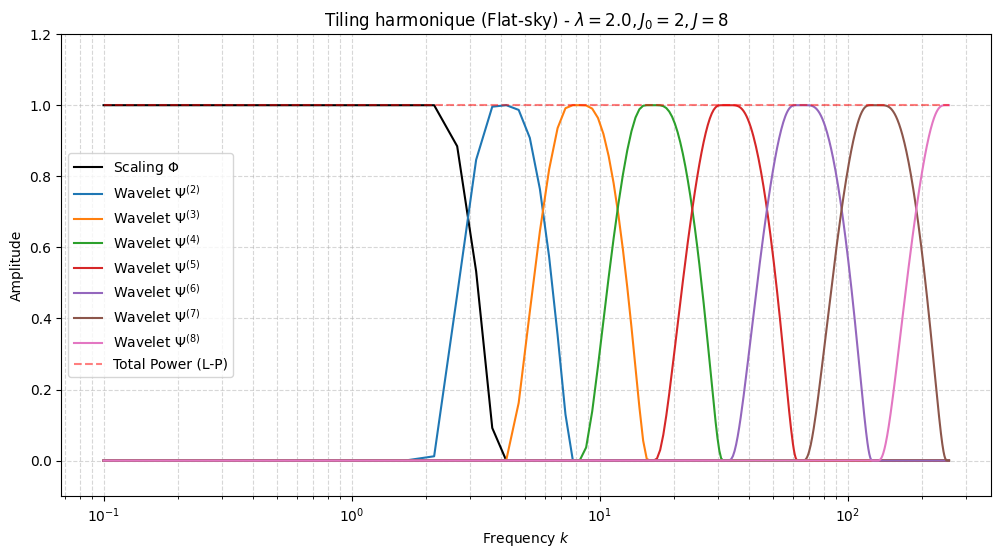

Écart max à la condition de Littlewood-Paley : 8.58e-13


In [8]:
L = 256      # Bande passante maximale 
lam = 2.0    # Paramètre de dilation lambda 
j0 = 2       # Échelle minimale 
J = int(np.ceil(np.log(L-1) / np.log(lam))) # Échelle max 

k_vals = np.linspace(0.1, L, 500)
scales_j = np.arange(j0, J + 1)

# Calcul des noyaux
phi_vals = np.array([scaling_function_kernel(k, lam, j0) for k in k_vals])
psi_kernels = []
for j in scales_j:
    psi_j = np.array([kappa_lambda(k / (lam**j), lam) for k in k_vals])
    psi_kernels.append(psi_j)

# --- Vérification de la condition de Littlewood-Paley ---
# Somme des carrés : |Phi|^2 + sum(|Psi_j|^2) [cite: 225, 289]
lp_condition = phi_vals**2 + np.sum([p**2 for p in psi_kernels], axis=0)

# Visualisation
plt.figure(figsize=(12, 6))
plt.plot(k_vals, phi_vals, 'k', label=r'Scaling $\Phi$')
for i, j in enumerate(scales_j):
    plt.plot(k_vals, psi_kernels[i], label=f'Wavelet $\Psi^{{({j})}}$')

plt.plot(k_vals, lp_condition, '--', color='red', alpha=0.5, label='Total Power (L-P)')
plt.xscale('log')
plt.ylim(-0.1, 1.2)
plt.title(f"Tiling harmonique (Flat-sky) - $\lambda={lam}, J_0={j0}, J={J}$")
plt.xlabel("Frequency $k$")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

print(f"Écart max à la condition de Littlewood-Paley : {np.max(np.abs(lp_condition - 1.0)):.2e}")

# Linear scale

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def s_function(t):
    """32"""
    if -1 < t < 1:
        return np.exp(-1.0 / (1.0 - t**2))
    return 0.0

def s_linear_function(x, B):
    """Mapping de s(t) sur un intervalle linéaire de largeur B."""
    # Mappe [0, B] vers (-1, 1)
    if 0 < x < B:
        return s_function((2.0 * x / B) - 1.0)
    return 0.0

def k_linear_transition(x, B):
    """Rampe de transition smooth de 1 à 0 sur l'intervalle [0, B]"""
    if x <= 0:
        return 1.0
    if x >= B:
        return 0.0
    
    # Intégration pour obtenir une décroissance lisse (même principe que ce qui est fait dans l'équation 33)
    num, _ = quad(lambda xp: s_linear_function(xp, B)**2, x, B)
    den, _ = quad(lambda xp: s_linear_function(xp, B)**2, 0.0, B)
    return num / den

def kappa_linear(k, j, B, k_start):
    """
    Noyau de l'ondelette linéaire à l'échelle j.
    Basé sur une différence de fonctions de transition pour téléscoper.
    """
    # Décalage linéaire pour l'échelle j et j-1
    shift_j = k_start + j * B
    shift_prev = k_start + (j - 1) * B
    
    val = k_linear_transition(k - shift_j, B) - k_linear_transition(k - shift_prev, B)
    return np.sqrt(max(val, 0))

def scaling_linear(k, k_start, B):
    """Fonction de mise à l'échelle linéaire (Scaling function)."""
    return np.sqrt(k_linear_transition(k - k_start, B))

<>:26: SyntaxWarning: invalid escape sequence '\P'
<>:26: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_346702/2046883601.py:26: SyntaxWarning: invalid escape sequence '\P'
  plt.plot(k_vals, psi_kernels[i], label=f'Wavelet $\Psi^{{({j})}}$')


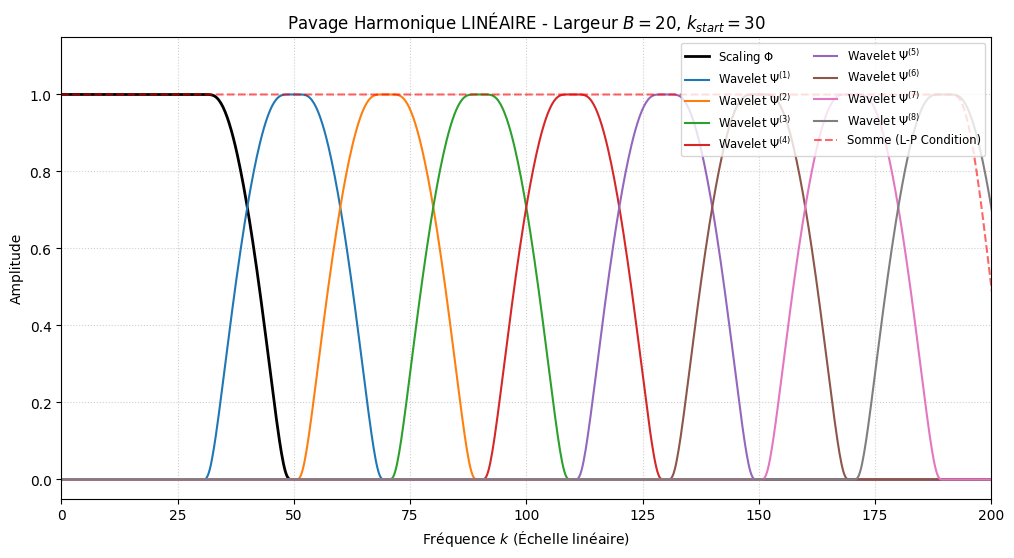

Erreur max de reconstruction : 7.11e-15


In [6]:
# Paramètres du pavage linéaire
L = 200            # Fréquence maximale
B = 20             # Largeur de bande linéaire de chaque ondelette (Delta k)
k_start = 30       # Fréquence où la fonction de scaling commence à chuter
J = int((L - k_start) // B)  # Nombre d'échelles

k_vals = np.linspace(0, L + 20, 1000)
scales_j = np.arange(1, J + 1)

# Calcul des filtres
phi_vals = np.array([scaling_linear(k, k_start, B) for k in k_vals])
psi_kernels = []
for j in scales_j:
    psi_j = np.array([kappa_linear(k, j, B, k_start) for k in k_vals])
    psi_kernels.append(psi_j)

# --- Vérification Littlewood-Paley (Échelle Linéaire) ---
# Somme des carrés : |Phi|^2 + sum(|Psi_j|^2)
lp_condition = phi_vals**2 + np.sum([p**2 for p in psi_kernels], axis=0)

# Visualisation
plt.figure(figsize=(12, 6))
plt.plot(k_vals, phi_vals, 'k', lw=2, label=r'Scaling $\Phi$')

for i, j in enumerate(scales_j):
    plt.plot(k_vals, psi_kernels[i], label=f'Wavelet $\Psi^{{({j})}}$')

plt.plot(k_vals, lp_condition, '--', color='red', alpha=0.6, label='Somme (L-P Condition)')

plt.ylim(-0.05, 1.15)
plt.xlim(0, L)
plt.title(f"Pavage Harmonique LINÉAIRE - Largeur $B={B}$, $k_{{start}}={k_start}$")
plt.xlabel("Fréquence $k$ (Échelle linéaire)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right', ncol=2, fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Erreur max de reconstruction : {np.max(np.abs(lp_condition[:int(L*0.9)] - 1.0)):.2e}")

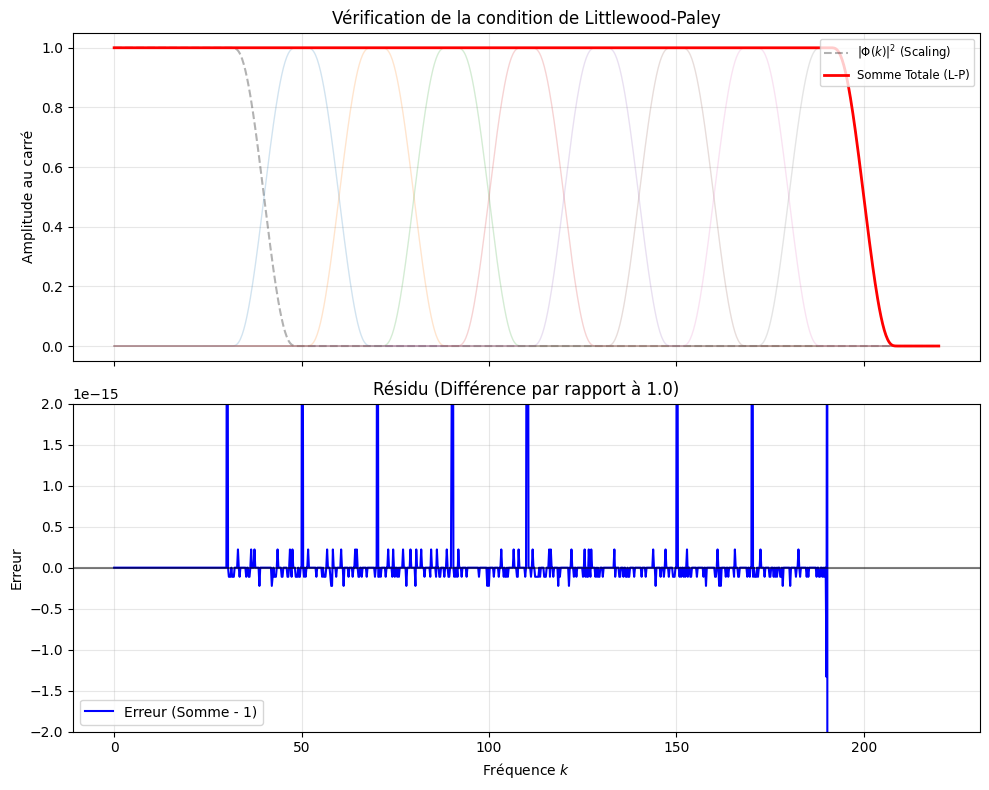

Erreur moyenne absolue : 7.22e-03


In [7]:
# 1. Calcul de la condition de Littlewood-Paley (somme des carrés)
phi_sq = phi_vals**2
psi_sq_sum = np.sum([p**2 for p in psi_kernels], axis=0)
lp_sum = phi_sq + psi_sq_sum

# 2. Calcul de l'erreur par rapport à l'unité
error = lp_sum - 1.0

# --- Création du Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Premier subplot : La valeur de la somme (doit valoir 1)
ax1.plot(k_vals, phi_sq, 'k--', alpha=0.3, label=r'$|\Phi(k)|^2$ (Scaling)')
for i, j in enumerate(scales_j):
    ax1.plot(k_vals, psi_kernels[i]**2, alpha=0.2, lw=1)
ax1.plot(k_vals, lp_sum, 'r', lw=2, label='Somme Totale (L-P)')
ax1.set_ylabel('Amplitude au carré')
ax1.set_title('Vérification de la condition de Littlewood-Paley')
ax1.legend(loc='upper right', fontsize='small')
ax1.grid(True, alpha=0.3)

# Second subplot : La différence (Erreur résiduelle)
# On se concentre sur la zone où les filtres sont définis
mask = k_vals < L 
ax2.plot(k_vals[mask], error[mask], 'b', label='Erreur (Somme - 1)')
ax2.axhline(0, color='black', linestyle='-', alpha=0.5)
ax2.set_ylabel('Erreur')
ax2.set_xlabel('Fréquence $k$')
ax2.set_title('Résidu (Différence par rapport à 1.0)')
# On ajuste l'échelle y pour voir la précision numérique (souvent 1e-15)
ax2.set_ylim(-2e-15, 2e-15) 
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Erreur moyenne absolue : {np.mean(np.abs(error[mask])):.2e}")

<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_346702/1877176536.py:59: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Pavage pour carte {resolution_carte}px (Nyquist L={resolution_carte//2}, $\lambda={lam_final:.2f}$)")


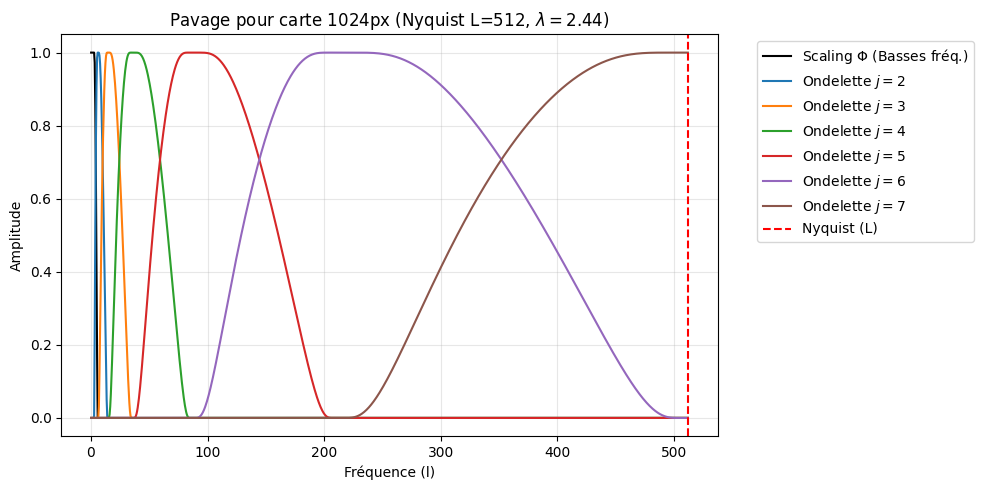

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def s_function(t):
    return np.exp(-1.0 / (1.0 - t**2)) if -1 < t < 1 else 0.0

def k_lambda_function(t, lam):
    if t <= 1.0/lam: return 1.0
    if t >= 1.0: return 0.0
    s_lam = lambda x: s_function((2.0 * lam / (lam - 1.0)) * (x - 1.0/lam) - 1.0)
    num, _ = quad(lambda tp: (s_lam(tp)**2) / tp, t, 1.0)
    den, _ = quad(lambda tp: (s_lam(tp)**2) / tp, 1.0/lam, 1.0)
    return num / den

def get_wavelet_tiling(map_res, n_bands_target=6, j0=2):
    """
    Crée les bandes d'ondelettes adaptées à la taille de la carte.
    L : Limite de Nyquist (map_res / 2).
    n_bands_target : Nombre de bandes d'ondelettes souhaitées.
    """
    L = map_res // 2  
    
    # On ajuste lambda pour obtenir à peu près le nombre de bandes voulu
    # L = lam^J => lam = L^(1/J)
    lam = L**(1.0 / (n_bands_target + j0)) 
    
    # Calcul de l'échelle maximale pour atteindre L 
    J = int(np.ceil(np.log(L-1) / np.log(lam))) 
    
    k_vals = np.linspace(0.1, L, 1000)
    scales_j = np.arange(j0, J + 1)
    
    # Calcul des noyaux [cite: 285, 257]
    phi_vals = np.array([np.sqrt(k_lambda_function(k / (lam**j0), lam)) for k in k_vals])
    psi_kernels = []
    for j in scales_j:
        # Eq. 34 & 35 : kappa_j(l) = sqrt(k(l/lam^(j+1)) - k(l/lam^j))
        psi_j = np.array([np.sqrt(max(k_lambda_function(k / (lam**(j+1)), lam) - 
                                     k_lambda_function(k / (lam**j), lam), 0)) for k in k_vals])
        psi_kernels.append(psi_j)
        
    return k_vals, phi_vals, psi_kernels, lam, J

# --- Paramètres ---
resolution_carte = 1024 # pixels
nb_bandes_voulu = 5

k, phi, psis, lam_final, J_final = get_wavelet_tiling(resolution_carte, nb_bandes_voulu)

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(k, phi, 'k', label=r'Scaling $\Phi$ (Basses fréq.)')
for i, psi in enumerate(psis):
    plt.plot(k, psi, label=f'Ondelette $j={i+2}$')

# Vérification Nyquist
plt.axvline(x=resolution_carte//2, color='red', linestyle='--', label='Nyquist (L)')
plt.title(f"Pavage pour carte {resolution_carte}px (Nyquist L={resolution_carte//2}, $\lambda={lam_final:.2f}$)")
plt.xlabel("Fréquence (l)")
plt.ylabel("Amplitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()